# Aula 03 — EDA sobre KPM (trilha offline)

**Fonte obrigatória do projeto:** `code/datasets/kpm-ue-tp-sample/` (SQLite + JSONL).

Objetivos:
1. Inspecionar schema e qualidade
2. Duas consultas SQL/pandas (contagem por fase; estatísticas de vazão/PRB/delay)
3. Dois gráficos (série temporal e boxplot por fase)

> InfluxDB / stack E2 ao vivo são **opcionais** e não substituem este notebook na avaliação.


In [1]:
from pathlib import Path
try:
    from IPython.display import display
except ImportError:
    def display(x):
        print(x)
import json
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Caminho relativo a code/notebooks/
SAMPLE = Path("../datasets/kpm-ue-tp-sample")
DB = SAMPLE / "kpm.sqlite"
JSONL = SAMPLE / "kpm.jsonl"
assert DB.is_file(), f"Amostra ausente: {DB.resolve()}"
print("DB:", DB.resolve())
print("JSONL lines:", sum(1 for _ in JSONL.open()))


DB: /home/wsl/Documents/learning/data-open-ran/code/datasets/kpm-ue-tp-sample/kpm.sqlite
JSONL lines: 100


## 1. Schema e amostra bruta


In [2]:
con = sqlite3.connect(DB)
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", con)
display(tables)

schema = pd.read_sql("PRAGMA table_info(kpm_samples)", con)
display(schema)

raw = pd.read_sql(
    """
    SELECT id, run_id, phase, sample_index, ingested_at,
           substr(payload_json, 1, 120) AS payload_preview
    FROM kpm_samples
    ORDER BY phase, sample_index
    LIMIT 8
    """,
    con,
)
display(raw)


,name
0,kpm_samples
1,runs
2,sqlite_sequence


,cid,name,type,notnull,dflt_value,pk
0,0,id,INTEGER,0,None,1
1,1,run_id,TEXT,1,None,0
2,2,phase,TEXT,1,None,0
3,3,sample_index,INTEGER,1,None,0
4,4,ingested_at,TEXT,1,None,0
5,5,source_path,TEXT,1,None,0
6,6,payload_json,TEXT,1,None,0


,id,run_id,phase,sample_index,ingested_at,payload_preview
0,1,ue-tp-20260804-174422,baseline,0,2026-08-04T20:44:22.310716+00:00,"{""DRB.RlcSduDelayDl"": 55.0, ""DRB.UEThpUl"": 4.4..."
1,2,ue-tp-20260804-174422,baseline,1,2026-08-04T20:44:22.310716+00:00,"{""DRB.RlcSduDelayDl"": 218.0, ""DRB.UEThpUl"": 3...."
2,3,ue-tp-20260804-174422,baseline,2,2026-08-04T20:44:22.310716+00:00,"{""DRB.RlcSduDelayDl"": 137.0, ""DRB.UEThpUl"": 3...."
3,4,ue-tp-20260804-174422,baseline,3,2026-08-04T20:44:22.310716+00:00,"{""DRB.RlcSduDelayDl"": 171.0, ""DRB.UEThpUl"": 3...."
4,5,ue-tp-20260804-174422,baseline,4,2026-08-04T20:44:22.310716+00:00,"{""DRB.RlcSduDelayDl"": 39.0, ""DRB.UEThpUl"": 3.7..."
5,6,ue-tp-20260804-174422,baseline,5,2026-08-04T20:44:22.310716+00:00,"{""DRB.RlcSduDelayDl"": 45.0, ""DRB.UEThpUl"": 3.7..."
6,7,ue-tp-20260804-174422,baseline,6,2026-08-04T20:44:22.310716+00:00,"{""DRB.RlcSduDelayDl"": 161.0, ""DRB.UEThpUl"": 3...."
7,8,ue-tp-20260804-174422,baseline,7,2026-08-04T20:44:22.310716+00:00,"{""DRB.RlcSduDelayDl"": 184.0, ""DRB.UEThpUl"": 3...."


## 2. Query SQL — contagem e qualidade por fase


In [3]:
counts = pd.read_sql(
    """
    SELECT phase, COUNT(*) AS n,
           COUNT(DISTINCT run_id) AS runs,
           SUM(CASE WHEN payload_json IS NULL OR payload_json = '' THEN 1 ELSE 0 END) AS empty_payload
    FROM kpm_samples
    GROUP BY phase
    ORDER BY phase
    """,
    con,
)
display(counts)
assert counts["empty_payload"].sum() == 0, "Há payloads vazios — investigar qualidade"
print("OK — sem payload vazio")


,phase,n,runs,empty_payload
0,baseline,20,1,0
1,recovery,20,1,0
2,stress,60,1,0


OK — sem payload vazio


## 3. Extrair métricas (ETL leve) e estatísticas


In [4]:
rows = pd.read_sql(
    "SELECT run_id, phase, sample_index, ingested_at, payload_json FROM kpm_samples",
    con,
)

def expand(row):
    m = json.loads(row["payload_json"])
    return pd.Series({
        "DRB.UEThpUl": m.get("DRB.UEThpUl"),
        "DRB.RlcSduDelayDl": m.get("DRB.RlcSduDelayDl"),
        "RRU.PrbTotUl": m.get("RRU.PrbTotUl"),
    })

metrics = rows.join(rows.apply(expand, axis=1))
display(metrics.groupby("phase")[["DRB.UEThpUl"]].describe().round(2))
display(metrics.groupby("phase")[["DRB.RlcSduDelayDl"]].describe().round(2))
display(metrics.groupby("phase")[["RRU.PrbTotUl"]].describe().round(2))


DRB.UEThpUl                                                           \
               count      mean       std    min       25%       50%       75%   
phase                                                                           
baseline        20.0      3.72      0.24   3.00      3.72      3.72      3.72   
recovery        20.0   8619.34  38530.41   3.00      3.72      3.72      3.72   
stress          60.0  78383.75  10505.39  15.16  79142.12  80023.68  81064.92   

                     
                max  
phase                
baseline       4.46  
recovery  172316.90  
stress     82823.86

DRB.RlcSduDelayDl                                                 \
                     count    mean     std     min     25%    50%     75%   
phase                                                                       
baseline              20.0   55.25   76.04    0.00    0.00    0.0  105.50   
recovery              20.0   78.85  133.79    0.00    0.00    0.0  107.25   
stress                60.0  161.98   19.46  133.74  153.76  158.9  166.80   

                  
             max  
phase             
baseline  218.00  
recovery  470.00  
stress    264.75

RRU.PrbTotUl                                           
                count   mean    std  min   25%   50%   75%   max
phase                                                           
baseline         20.0   2.00   0.00  2.0   2.0   2.0   2.0   2.0
recovery         20.0   2.95   4.25  2.0   2.0   2.0   2.0  21.0
stress           60.0  97.33  12.52  2.0  99.0  99.0  99.0  99.0

## 4. Query pandas — baseline vs stress (vazão UL)


In [5]:
cmp = (
    metrics.groupby("phase")["DRB.UEThpUl"]
    .agg(n="count", mean="mean", median="median", p95=lambda s: s.quantile(0.95))
    .round(2)
)
display(cmp)

# KPI preliminar (exemplo Checkpoint 1): razão mediana stress/baseline
base = cmp.loc["baseline", "median"] if "baseline" in cmp.index else float("nan")
stress = cmp.loc["stress", "median"] if "stress" in cmp.index else float("nan")
print(f"KPI preliminar — mediana UEThpUl stress/baseline = {stress / base if base else float('nan'):.2f}")


,n,mean,median,p95
phase,,,,
baseline,20,3.72,3.72,3.76
recovery,20,8619.34,3.72,8619.38
stress,60,78383.75,80023.68,82189.53


KPI preliminar — mediana UEThpUl stress/baseline = 21511.74


## 5. Visualização 1 — série por fase


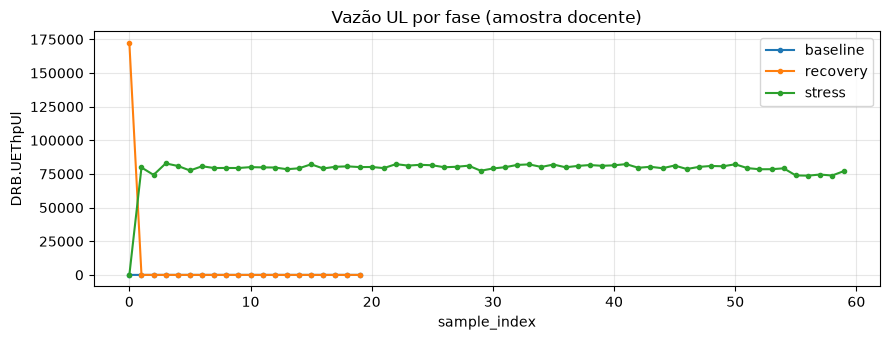

In [6]:
fig, ax = plt.subplots(figsize=(9, 3.5))
for phase, g in metrics.groupby("phase"):
    ax.plot(g["sample_index"], g["DRB.UEThpUl"], marker="o", ms=3, label=phase)
ax.set_xlabel("sample_index")
ax.set_ylabel("DRB.UEThpUl")
ax.set_title("Vazão UL por fase (amostra docente)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Visualização 2 — boxplot PRB / delay


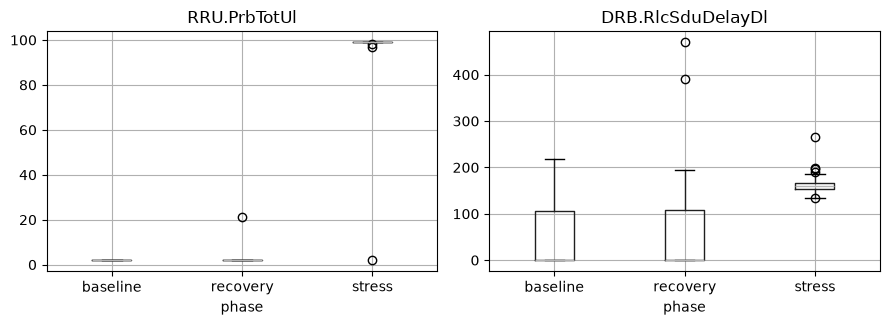

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
metrics.boxplot(column="RRU.PrbTotUl", by="phase", ax=axes[0])
axes[0].set_title("RRU.PrbTotUl")
axes[0].set_xlabel("phase")
metrics.boxplot(column="DRB.RlcSduDelayDl", by="phase", ax=axes[1])
axes[1].set_title("DRB.RlcSduDelayDl")
axes[1].set_xlabel("phase")
fig.suptitle("")
plt.tight_layout()
plt.show()
con.close()


## Checkpoint 1 — o que registrar

- Contagem por fase e ausência de nulos críticos
- 2 indicadores preliminares (ex.: mediana `DRB.UEThpUl`, p95 `RRU.PrbTotUl` por fase)
- 1 insight: stress eleva PRB/vazão e/ou delay vs baseline?

Próximo notebook: `aula03_etl_kpm.ipynb` (tabela tipada + export).
